# makemore: part 5

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [2]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
print(len(words))
print(max(len(w) for w in words))
print(words[:8])

32033
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [3]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [4]:
# shuffle up the words
import random
random.seed(42)
random.shuffle(words)

In [5]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):
  X, Y = [], []

  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X, device=device)
  Y = torch.tensor(Y, device=device)
  print(X.shape, Y.shape)
  return X, Y

n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [6]:
for x,y in zip(Xtr[:20], Ytr[:20]):
  print(''.join(itos[ix.item()] for ix in x), '-->', itos[y.item()])

... --> y
..y --> u
.yu --> h
yuh --> e
uhe --> n
hen --> g
eng --> .
... --> d
..d --> i
.di --> o
dio --> n
ion --> d
ond --> r
ndr --> e
dre --> .
... --> x
..x --> a
.xa --> v
xav --> i
avi --> e


In [7]:
# Layers developed in part 3.
class Linear:

  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out), device=device) / fan_in**0.5
    self.bias = torch.zeros(fan_out, device=device) if bias else None

  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out

  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])


class BatchNorm1d:

  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    # parameters trained with backprop
    self.gamma = torch.ones(dim, device=device)
    self.beta = torch.zeros(dim, device=device)
    # buffers trained with a momentum update
    self.running_mean = torch.zeros(dim, device=device)
    self.running_var = torch.ones(dim, device=device)

  def __call__(self, x):
    if self.training:
      xmean = x.mean(0, keepdim=True)
      xvar = x.var(0, keepdim=True)
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
    self.out = self.gamma * xhat + self.beta
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out

  def parameters(self):
    return [self.gamma, self.beta]


class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []

In [8]:
torch.manual_seed(42); # seed rng for reproducibility

In [9]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

C = torch.randn((vocab_size, n_embd), device=device)
layers = [
  Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(n_hidden, vocab_size),
]

with torch.no_grad():
  layers[-1].weight *= 0.1 # last layer less confident

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))
for p in parameters:
  p.requires_grad = True

12097


In [10]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), device=device)
  Xb, Yb = Xtr[ix], Ytr[ix]

  # forward pass
  emb = C[Xb]
  x = emb.view(emb.shape[0], -1)
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, Yb)

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  lr = 0.1 if i < 150000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  if i % 10000 == 0:
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

      0/ 200000: 3.3078


  10000/ 200000: 2.5182


  20000/ 200000: 2.3602


  30000/ 200000: 2.1772


  40000/ 200000: 1.7950


...

 150000/ 200000: 2.1303


 160000/ 200000: 2.6925


 170000/ 200000: 2.6305


 180000/ 200000: 2.0180


 190000/ 200000: 2.0573


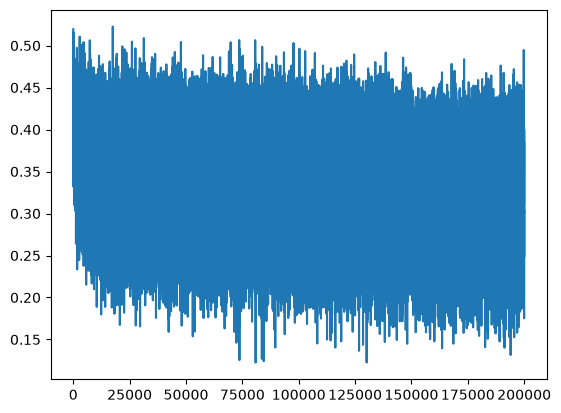

In [11]:
plt.plot(lossi)

In [12]:
# put layers into eval mode
for layer in layers:
  layer.training = False

In [13]:
@torch.no_grad()
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x]
  out = emb.view(emb.shape[0], -1)
  for layer in layers:
    out = layer(out)
  loss = F.cross_entropy(out, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.05900502204895
val 2.10568904876709


In [14]:
# sample from the model
for _ in range(20):

  out = []
  context = [0] * block_size
  while True:
    emb = C[torch.tensor([context], device=device)]
    x = emb.view(emb.shape[0], -1)
    for layer in layers:
      x = layer(x)
    probs = F.softmax(x, dim=1)
    ix = torch.multinomial(probs, num_samples=1).item()
    context = context[1:] + [ix]
    out.append(ix)
    if ix == 0:
      break

  print(''.join(itos[i] for i in out))

ire.
takayler.
arnalim.
bhon.
yurindley.
per.
terrioleigh.
deugio.
her.
anaiyi.
jashden.
jinnon.
sivi.
semari.
cheem.
lison.
dia.
morgi.
alah.
elda.


In [15]:
lossi[:10]

[0.5195363163948059,
 0.5156134963035583,
 0.5090094804763794,
 0.508129894733429,
 0.49662408232688904,
 0.4950294494628906,
 0.4966511130332947,
 0.4813360273838043,
 0.5027610063552856,
 0.49942898750305176]

In [16]:
torch.tensor(lossi[:10]).view(2, 5)

tensor([[0.5195, 0.5156, 0.5090, 0.5081, 0.4966],
        [0.4950, 0.4967, 0.4813, 0.5028, 0.4994]])

In [17]:
torch.tensor(lossi[:10]).view(5, 2)

tensor([[0.5195, 0.5156],
        [0.5090, 0.5081],
        [0.4966, 0.4950],
        [0.4967, 0.4813],
        [0.5028, 0.4994]])

In [18]:
torch.tensor(lossi[:10]).view(-1, 5)

tensor([[0.5195, 0.5156, 0.5090, 0.5081, 0.4966],
        [0.4950, 0.4967, 0.4813, 0.5028, 0.4994]])

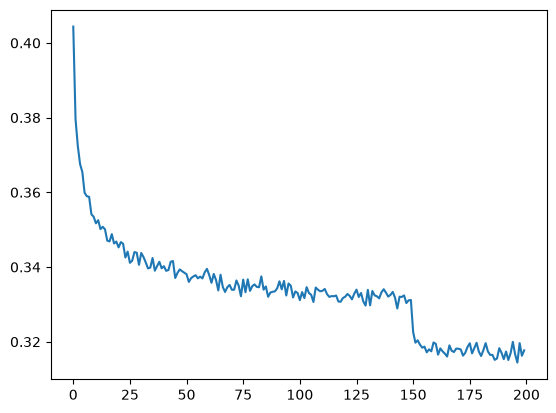

In [19]:
# Average every 1000 consecutive losses.
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))

## pytorchifying the code

Move the embedding lookup and flattening into layers, then collect the layers in a sequential model.

In [20]:
class Embedding:

  def __init__(self, num_embeddings, embedding_dim):
    self.weight = torch.randn((num_embeddings, embedding_dim), device=device)

  def __call__(self, IX):
    self.out = self.weight[IX]
    return self.out

  def parameters(self):
    return [self.weight]


class Flatten:
  def __call__(self, x):
    self.out = x.view(x.shape[0], -1)
    return self.out
  def parameters(self):
    return []

In [21]:
# Put every forward operation in the layers list.
torch.manual_seed(42)
n_embd = 10
n_hidden = 200

layers = [
  Embedding(vocab_size, n_embd),
  Flatten(), Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(n_hidden, vocab_size),
]

with torch.no_grad():
  layers[-1].weight *= 0.1

parameters = [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))
for p in parameters:
  p.requires_grad = True

12097


In [22]:
# Run one step with the simpler forward pass.
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), device=device)
  Xb, Yb = Xtr[ix], Ytr[ix]

  x = Xb
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, Yb)

  for p in parameters:
    p.grad = None
  loss.backward()

  lr = 0.1 if i < 150000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  lossi.append(loss.log10().item())
  break

loss

tensor(3.3078, device='cuda:0', grad_fn=<NllLossBackward0>)

torch.nn :Containers: Sequential: https://docs.pytorch.org/docs/2.13/generated/torch.nn.Sequential.html

In [23]:
class Sequential:

  def __init__(self, layers):
    self.layers = layers

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    self.out = x
    return self.out

  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

In [24]:
# The naked list is now one model.
torch.manual_seed(42)
n_embd = 10
n_hidden = 200

model = Sequential([
  Embedding(vocab_size, n_embd),
  Flatten(), Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(n_hidden, vocab_size),
])

with torch.no_grad():
  model.layers[-1].weight *= 0.1

parameters = model.parameters()
print(sum(p.nelement() for p in parameters))
for p in parameters:
  p.requires_grad = True

12097


In [25]:
# Run one step through Sequential.
ix = torch.randint(0, Xtr.shape[0], (batch_size,), device=device)
Xb, Yb = Xtr[ix], Ytr[ix]
logits = model(Xb)
loss = F.cross_entropy(logits, Yb)

for p in parameters:
  p.grad = None
loss.backward()

for p in parameters:
  p.data += -0.1 * p.grad

loss

tensor(3.3078, device='cuda:0', grad_fn=<NllLossBackward0>)

In [26]:
# BatchNorm cannot estimate variance from one number.
torch.tensor([5.0], device=device).var()

/tmp/ipykernel_44013/868664515.py:2: UserWarning: var(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1879.)
  torch.tensor([5.0], device=device).var()


tensor(nan, device='cuda:0')

In [27]:
# Evaluation mode makes BatchNorm use its running statistics.
for layer in model.layers:
  layer.training = False

In [28]:
@torch.no_grad()
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  logits = model(x)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 3.2675657272338867
val 3.2682688236236572


In [ ]:
# sample from the untrained model
for _ in range(20):

  out = []
  context = [0] * block_size
  while True:
    logits = model(torch.tensor([context], device=device))
    probs = F.softmax(logits, dim=1)
    ix = torch.multinomial(probs, num_samples=1).item()
    context = context[1:] + [ix]
    out.append(ix)
    if ix == 0:
      break

  print(''.join(itos[i] for i in out))
  # gibberish

ajokyvgrzppeopkgbr.
eqwskmniriphqiojfibjxqsvf.
btwupwpoqtgzmiirwxiybqoiohyuqucicpmoph.
i.
smqolvhqsugoqmkfzwltv.
vlhcvqdstwdnzqorkeezuruedt.
hzdikhtptrynfpzykyrqjytrjyjjnfwkzgtaopnzzrzrrojdgceend.
qqzuigtgjpfvddmarifpkzp.
vgdcxklcncofrnclekelcfkgpplrgywuzjqckspcnpsjwzgkbcvxkdgacqotnlzxcrqzdkgvckzkl.
.
rcxg.
socsseluqdvqnf.
ejpmacbgm.
tiewwplkfxsgkmplduljhqyxztuepoyabrcvelvvkjyabzqmkkhnv.
vhnpsetlgsldge.
hdhez.
paixoikvq.
nasoxsufjtwnxapwybftyzylaeicmrhrphmllgpugsxuguuflgcbbuusnzor.
hsneawwrwuisfzgrmnqgatlowzhgmcllhfmdmjdijzvhqclkeabbxikunojephk.
epftdrmibrzpxubijf.


## a longer context

Take eight characters as input before changing the network structure.

In [30]:
block_size = 8

Xtr,  Ytr  = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte,  Yte  = build_dataset(words[n2:])

torch.Size([182625, 8]) torch.Size([182625])
torch.Size([22655, 8]) torch.Size([22655])
torch.Size([22866, 8]) torch.Size([22866])


In [31]:
for x,y in zip(Xtr[:20], Ytr[:20]):
  print(''.join(itos[ix.item()] for ix in x), '-->', itos[y.item()])

........ --> y
.......y --> u
......yu --> h
.....yuh --> e
....yuhe --> n
...yuhen --> g
..yuheng --> .
........ --> d
.......d --> i
......di --> o
.....dio --> n
....dion --> d
...diond --> r
..diondr --> e
.diondre --> .
........ --> x
.......x --> a
......xa --> v
.....xav --> i
....xavi --> e


In [32]:
# Flat network with eight characters of context.
torch.manual_seed(42)
n_embd = 10
n_hidden = 200

model = Sequential([
  Embedding(vocab_size, n_embd),
  Flatten(), Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(n_hidden, vocab_size),
])

with torch.no_grad():
  model.layers[-1].weight *= 0.1

parameters = model.parameters()
print(sum(p.nelement() for p in parameters))
for p in parameters:
  p.requires_grad = True

22097


In [33]:
# Check the first iteration before the full run.
max_steps = 200000
batch_size = 32

for i in range(max_steps):
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), device=device)
  Xb, Yb = Xtr[ix], Ytr[ix]
  logits = model(Xb)
  loss = F.cross_entropy(logits, Yb)

  for p in parameters:
    p.grad = None
  loss.backward()

  for p in parameters:
    p.data += -0.1 * p.grad
  break

loss

tensor(3.2805, device='cuda:0', grad_fn=<NllLossBackward0>)

In [34]:
# Reinitialize and train the eight-character flat baseline.
torch.manual_seed(42)
n_embd = 10
n_hidden = 200

model = Sequential([
  Embedding(vocab_size, n_embd),
  Flatten(), Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(n_hidden, vocab_size),
])

with torch.no_grad():
  model.layers[-1].weight *= 0.1

parameters = model.parameters()
print(sum(p.nelement() for p in parameters))
for p in parameters:
  p.requires_grad = True

max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), device=device)
  Xb, Yb = Xtr[ix], Ytr[ix]
  logits = model(Xb)
  loss = F.cross_entropy(logits, Yb)

  for p in parameters:
    p.grad = None
  loss.backward()

  lr = 0.1 if i < 150000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  if i % 10000 == 0:
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

22097
      0/ 200000: 3.2805


  10000/ 200000: 2.4688


  20000/ 200000: 2.3219


  30000/ 200000: 2.0491


  40000/ 200000: 1.6061


...

 150000/ 200000: 1.9181


 160000/ 200000: 2.3047


 170000/ 200000: 2.5076


 180000/ 200000: 1.9797


 190000/ 200000: 1.9216


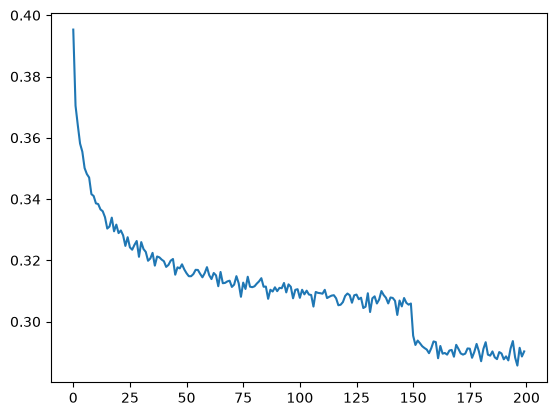

In [35]:
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))

In [36]:
for layer in model.layers:
  layer.training = False

split_loss('train')
split_loss('val')

train 1.9211441278457642
val 2.0316035747528076


In [37]:
# sample from the flat eight-character model
for _ in range(20):

  out = []
  context = [0] * block_size
  while True:
    logits = model(torch.tensor([context], device=device))
    probs = F.softmax(logits, dim=1)
    ix = torch.multinomial(probs, num_samples=1).item()
    context = context[1:] + [ix]
    out.append(ix)
    if ix == 0:
      break

  print(''.join(itos[i] for i in out))

ireb.
adayah.
aarnal.
maxhos.
youshus.
myler.
terrik.
eivin.
bugim.
herron.
ayi.
jashden.
miriah.
sivi.
semari.
cheem.
lison.
dione.
tonia.
awielda.


## the hierarchical network

Fuse consecutive pairs slowly instead of flattening all eight characters at once.

In [38]:
# Inspect a small batch as it moves through the flat network.
ix = torch.randint(0, Xtr.shape[0], (4,), device=device)
Xb, Yb = Xtr[ix], Ytr[ix]
Xb

tensor([[ 0,  0,  0,  0,  0,  0, 18,  9],
        [23,  1, 11,  5,  6,  9,  5, 12],
        [ 0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0, 11,  5, 12, 12, 25, 14]], device='cuda:0')

In [39]:
x = Xb
for layer in model.layers:
  x = layer(x)
  print(layer.__class__.__name__, tuple(x.shape))

Embedding (4, 8, 10)
Flatten (4, 80)
Linear (4, 200)
BatchNorm1d (4, 200)
Tanh (4, 200)
Linear (4, 27)


In [40]:
# Matrix multiplication only changes the last dimension.
(torch.randn((4, 80), device=device) @ torch.randn((80, 200), device=device) + torch.randn(200, device=device)).shape

torch.Size([4, 200])

In [41]:
(torch.randn((4, 5, 80), device=device) @ torch.randn((80, 200), device=device) + torch.randn(200, device=device)).shape

torch.Size([4, 5, 200])

In [42]:
e = model.layers[0](Xb)
e.shape

torch.Size([4, 8, 10])

In [43]:
e.view(4, -1).shape

torch.Size([4, 80])

In [44]:
list(range(10))[::2], list(range(10))[1::2]

([0, 2, 4, 6, 8], [1, 3, 5, 7, 9])

In [45]:
# Concatenate each even character with the following odd character.
explicit = torch.cat([e[:, ::2, :], e[:, 1::2, :]], dim=2)
explicit.shape

torch.Size([4, 4, 20])

In [46]:
# A view gives the same grouping without copying memory.
torch.all(explicit == e.view(4, 4, 20))

tensor(True, device='cuda:0')

In [47]:
class FlattenConsecutive:

  def __init__(self, n):
    self.n = n

  def __call__(self, x):
    B, T, C = x.shape
    x = x.view(B, T//self.n, C*self.n)
    if x.shape[1] == 1:
      x = x.squeeze(1)
    self.out = x
    return self.out

  def parameters(self):
    return []

https://docs.pytorch.org/docs/2.13/generated/torch.squeeze.html

In [48]:
# FlattenConsecutive(8) recovers the flat network.
torch.manual_seed(42)
n_embd = 10
n_hidden = 200

model = Sequential([
  Embedding(vocab_size, n_embd),
  FlattenConsecutive(8), Linear(n_embd * 8, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(n_hidden, vocab_size),
])

with torch.no_grad():
  model.layers[-1].weight *= 0.1

parameters = model.parameters()
print(sum(p.nelement() for p in parameters))
for p in parameters:
  p.requires_grad = True

x = Xb
for layer in model.layers:
  x = layer(x)
  print(layer.__class__.__name__, tuple(x.shape))

22097
Embedding (4, 8, 10)
FlattenConsecutive (4, 80)
Linear (4, 200)
BatchNorm1d (4, 200)
Tanh (4, 200)
Linear (4, 27)


In [49]:
# First version of the hierarchical network.
torch.manual_seed(42)
n_embd = 10
n_hidden = 200

model = Sequential([
  Embedding(vocab_size, n_embd),
  FlattenConsecutive(2), Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(n_hidden, vocab_size),
])

with torch.no_grad():
  model.layers[-1].weight *= 0.1

parameters = model.parameters()
print(sum(p.nelement() for p in parameters))
for p in parameters:
  p.requires_grad = True

x = Xb
for layer in model.layers:
  x = layer(x)
  print(layer.__class__.__name__, tuple(x.shape))

170897
Embedding (4, 8, 10)
FlattenConsecutive (4, 4, 20)
Linear (4, 4, 200)
BatchNorm1d (4, 4, 200)
Tanh (4, 4, 200)
FlattenConsecutive (4, 2, 400)
Linear (4, 2, 200)
BatchNorm1d (4, 2, 200)
Tanh (4, 2, 200)
FlattenConsecutive (4, 400)
Linear (4, 200)
BatchNorm1d (4, 200)
Tanh (4, 200)
Linear (4, 27)


In [50]:
# Use 68 hidden units to keep about the same parameter count as the flat model.
torch.manual_seed(42)
n_embd = 10
n_hidden = 68

model = Sequential([
  Embedding(vocab_size, n_embd),
  FlattenConsecutive(2), Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(n_hidden, vocab_size),
])

with torch.no_grad():
  model.layers[-1].weight *= 0.1

parameters = model.parameters()
print(sum(p.nelement() for p in parameters))
for p in parameters:
  p.requires_grad = True

max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), device=device)
  Xb, Yb = Xtr[ix], Ytr[ix]
  logits = model(Xb)
  loss = F.cross_entropy(logits, Yb)

  for p in parameters:
    p.grad = None
  loss.backward()

  lr = 0.1 if i < 150000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  if i % 10000 == 0:
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

22397
      0/ 200000: 3.2861


  10000/ 200000: 1.9465


  20000/ 200000: 1.9651


  30000/ 200000: 2.4938


  40000/ 200000: 2.0298


...

 150000/ 200000: 2.1325


 160000/ 200000: 2.5286


 170000/ 200000: 2.4444


 180000/ 200000: 2.3240


 190000/ 200000: 1.9108


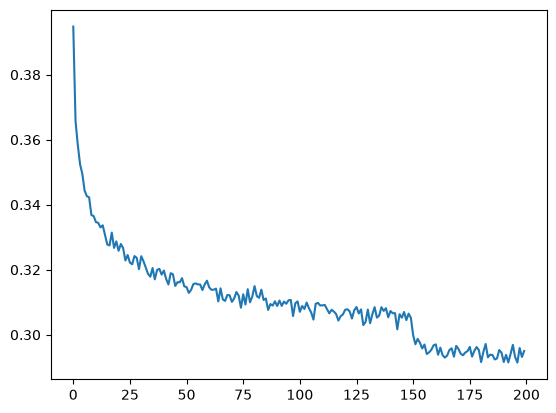

In [51]:
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))

In [52]:
for layer in model.layers:
  layer.training = False

split_loss('train')
split_loss('val')

train 1.941335678100586
val 2.0267722606658936


## fixing BatchNorm for three-dimensional inputs

The network runs, but the old BatchNorm keeps separate statistics for every sequence position.

In [53]:
ix = torch.randint(0, Xtr.shape[0], (32,), device=device)
Xb, Yb = Xtr[ix], Ytr[ix]

x = Xb
for layer in model.layers:
  x = layer(x)
  print(layer.__class__.__name__, tuple(x.shape))

Embedding (32, 8, 10)
FlattenConsecutive (32, 4, 20)
Linear (32, 4, 68)
BatchNorm1d (32, 4, 68)
Tanh (32, 4, 68)
FlattenConsecutive (32, 2, 136)
Linear (32, 2, 68)
BatchNorm1d (32, 2, 68)
Tanh (32, 2, 68)
FlattenConsecutive (32, 136)
Linear (32, 68)
BatchNorm1d (32, 68)
Tanh (32, 68)
Linear (32, 27)


In [54]:
model.layers[3].running_mean.shape

torch.Size([1, 4, 68])

In [55]:
e = torch.randn((32, 4, 68), device=device)
e.mean(0, keepdim=True).shape

torch.Size([1, 4, 68])

https://docs.pytorch.org/docs/2.13/generated/torch.mean.html

In [56]:
# Reduce both batch dimensions and keep only one statistic per channel.
e.mean((0, 1), keepdim=True).shape

torch.Size([1, 1, 68])

In [ ]:
class BatchNorm1d:

  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    self.gamma = torch.ones(dim, device=device)
    self.beta = torch.zeros(dim, device=device)
    self.running_mean = torch.zeros(dim, device=device)
    self.running_var = torch.ones(dim, device=device)

  def __call__(self, x):
    if self.training:
      if x.ndim == 2:
        dim = 0
      elif x.ndim == 3:
        dim = (0, 1)
      xmean = x.mean(dim, keepdim=True) # 1, 1, C
      xvar = x.var(dim, keepdim=True) # 1, 1, C
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # broadcast to B, T, C
    self.out = self.gamma * xhat + self.beta
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out

  def parameters(self):
    return [self.gamma, self.beta]

note that API in pytorch bn is different, expected inputs are (N, C) or (N, C, L) : https://docs.pytorch.org/docs/2.13/generated/torch.nn.BatchNorm1d.html

In [58]:
# Rebuild the model with the fixed BatchNorm and run one step.
torch.manual_seed(42)
n_embd = 10
n_hidden = 68

model = Sequential([
  Embedding(vocab_size, n_embd),
  FlattenConsecutive(2), Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(n_hidden, vocab_size),
])

with torch.no_grad():
  model.layers[-1].weight *= 0.1

parameters = model.parameters()
print(sum(p.nelement() for p in parameters))
for p in parameters:
  p.requires_grad = True

ix = torch.randint(0, Xtr.shape[0], (batch_size,), device=device)
Xb, Yb = Xtr[ix], Ytr[ix]
logits = model(Xb)
loss = F.cross_entropy(logits, Yb)

for p in parameters:
  p.grad = None
loss.backward()

for p in parameters:
  p.data += -0.1 * p.grad

x = Xb
for layer in model.layers:
  x = layer(x)
  print(layer.__class__.__name__, tuple(x.shape))

model.layers[3].running_mean.shape

22397
Embedding (32, 8, 10)
FlattenConsecutive (32, 4, 20)
Linear (32, 4, 68)
BatchNorm1d (32, 4, 68)
Tanh (32, 4, 68)
FlattenConsecutive (32, 2, 136)
Linear (32, 2, 68)
BatchNorm1d (32, 2, 68)
Tanh (32, 2, 68)
FlattenConsecutive (32, 136)
Linear (32, 68)
BatchNorm1d (32, 68)
Tanh (32, 68)
Linear (32, 27)


torch.Size([1, 1, 68])

In [59]:
# Reinitialize and train after the BatchNorm fix.
torch.manual_seed(42)
n_embd = 10
n_hidden = 68

model = Sequential([
  Embedding(vocab_size, n_embd),
  FlattenConsecutive(2), Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(n_hidden, vocab_size),
])

with torch.no_grad():
  model.layers[-1].weight *= 0.1

parameters = model.parameters()
print(sum(p.nelement() for p in parameters))
for p in parameters:
  p.requires_grad = True

max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), device=device)
  Xb, Yb = Xtr[ix], Ytr[ix]
  logits = model(Xb)
  loss = F.cross_entropy(logits, Yb)

  for p in parameters:
    p.grad = None
  loss.backward()

  lr = 0.1 if i < 150000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  if i % 10000 == 0:
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

22397
      0/ 200000: 3.2902


  10000/ 200000: 1.8848


  20000/ 200000: 2.0317


  30000/ 200000: 2.4088


  40000/ 200000: 1.9703


...

 150000/ 200000: 2.2514


 160000/ 200000: 2.5400


 170000/ 200000: 2.4922


 180000/ 200000: 2.2709


 190000/ 200000: 1.9274


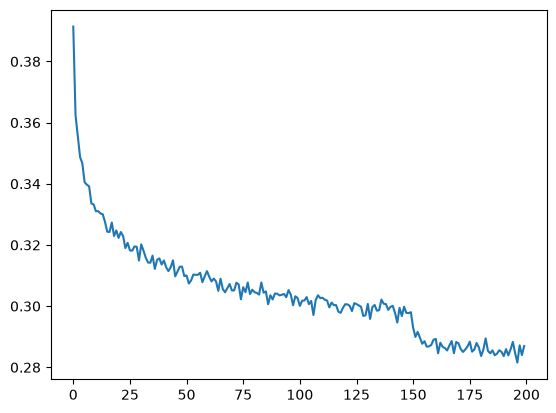

In [60]:
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))

In [61]:
for layer in model.layers:
  layer.training = False

split_loss('train')
split_loss('val')

train 1.9119702577590942
val 2.018342971801758


## scaling up the network

Keep the same hierarchy and give it larger embeddings and hidden layers.

In [62]:
torch.manual_seed(42)
n_embd = 24
n_hidden = 128

model = Sequential([
  Embedding(vocab_size, n_embd),
  FlattenConsecutive(2), Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(n_hidden, vocab_size),
])

with torch.no_grad():
  model.layers[-1].weight *= 0.1

parameters = model.parameters()
print(sum(p.nelement() for p in parameters))
for p in parameters:
  p.requires_grad = True

max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), device=device)
  Xb, Yb = Xtr[ix], Ytr[ix]
  logits = model(Xb)
  loss = F.cross_entropy(logits, Yb)

  for p in parameters:
    p.grad = None
  loss.backward()

  lr = 0.1 if i < 150000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  if i % 10000 == 0:
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

76579
      0/ 200000: 3.2798


  10000/ 200000: 1.8404


  20000/ 200000: 1.8708


  30000/ 200000: 2.4852


  40000/ 200000: 1.8218


...

 150000/ 200000: 2.0256


 160000/ 200000: 2.4925


 170000/ 200000: 2.2736


 180000/ 200000: 1.9415


 190000/ 200000: 1.8374


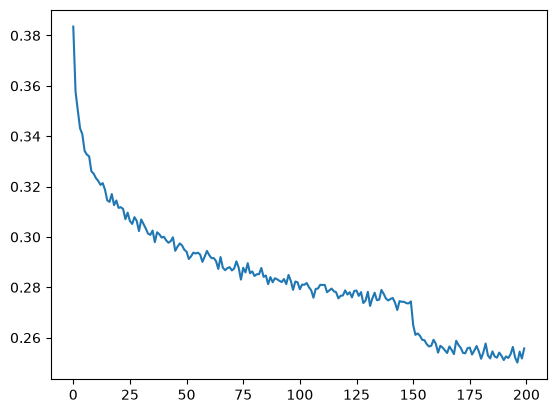

In [63]:
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))

The loss has a jump due to learning rate decay

In [64]:
for layer in model.layers:
  layer.training = False

split_loss('train')
split_loss('val')

train 1.7700707912445068
val 1.9927703142166138


### performance log

- original, 3-character context: train 2.058, val 2.105
- 8-character flat model: train 1.918, val 2.027
- hierarchical model: train 1.941, val 2.029
- fixed BatchNorm: train 1.912, val 2.022
- larger hierarchical model: train 1.769, val 1.993

In [65]:
# sample from the final model
for _ in range(20):

  out = []
  context = [0] * block_size
  while True:
    logits = model(torch.tensor([context], device=device))
    probs = F.softmax(logits, dim=1)
    ix = torch.multinomial(probs, num_samples=1).item()
    context = context[1:] + [ix]
    out.append(ix)
    if ix == 0:
      break

  print(''.join(itos[i] for i in out))

elisandre.
aarnal.
maximo.
yuqaiya.
mylei.
terrio.
eivin.
bubianne.
kaobie.
merandthusin.
brystephson.
khydee.
malico.
zela.
morgi.
alanie.
dakari.
jordanna.
noxxon.
johnpuertino.


## convolution preview

A convolution moves the same linear filter across a sequence and performs the loop efficiently.

In [66]:
for x,y in zip(Xtr[7:15], Ytr[7:15]):
  print(''.join(itos[ix.item()] for ix in x), '-->', itos[y.item()])

........ --> d
.......d --> i
......di --> o
.....dio --> n
....dion --> d
...diond --> r
..diondr --> e
.diondre --> .


In [ ]:
# forward a single example
logits = model(Xtr[[7]]) # create a batch with a single example using [[]]
logits.shape

torch.Size([1, 27])

In [ ]:
# forward all of them
logits = torch.zeros(8, vocab_size, device=device)
for i in range(8): # Currently 8 independent calls to model, but convolution can do this efficiently by sliding a window over the input sequence, which the for loop can be done(hidden) inside the kernels of CUDA
  logits[i] = model(Xtr[[7+i]])
logits.shape

torch.Size([8, 27])

In [ ]:
# convolution is a "for loop"
# allows us to forward Linear layers efficiently over space

#### From the hierarchical MLP to convolution

For one aligned context, `FlattenConsecutive(2) + Linear(2 * C_in, C_out)` joins adjacent vectors and applies the same linear map to every pair. This is equivalent to a 1D convolution with `kernel_size=2` and `stride=2`:

```text
8 characters -> 4 bigrams -> 2 four-character blocks -> 1 eight-character block
```

That computes one tree and one next-character prediction. To predict at every position of a long sequence, slide the same tree over the sequence instead of forwarding many overlapping context windows independently. A causal convolution performs this sliding loop inside optimized CPU/CUDA kernels and reuses intermediate features shared by neighboring trees.

Use `kernel_size=2`, `stride=1`, and exponentially increasing dilations:

| Layer | Dilation | Receptive field |
|---|---:|---:|
| 1 | 1 | 2 characters |
| 2 | 2 | 4 characters |
| 3 | 4 | 8 characters |

Conceptually, `h1[t]` combines nearby characters, `h2[t]` combines two 2-character representations two steps apart, and `h3[t]` combines two 4-character representations four steps apart. Left-only padding makes the convolution **causal**, so output `t` cannot see future characters.

PyTorch `Conv1d` expects `(B, C, T)`, whereas this notebook uses `(B, T, C)`, so transpose the last two dimensions around convolutional code. The final `Linear(n_hidden, vocab_size)` applied at every position is a `Conv1d(..., kernel_size=1)`.

> `stride=2` reproduces one non-overlapping tree; `stride=1` with dilations `1, 2, 4` slides that tree over all positions. This lecture implements the hierarchical structure, not the full WaveNet gated, residual, and skip-connection architecture.

Implementing `Linear`, `BatchNorm1d`, `Embedding`, activation layers, and containers such as `Sequential` on top of `torch.Tensor` reveals what PyTorch modules actually do: they package tensor operations, parameters, buffers, state, and composition behind a common interface. Having built these pieces ourselves, we can now switch to the better-tested `torch.nn` implementations without treating them as magic.

A large part of development is spent reading PyTorch documentation: What inputs does a layer accept? What shape does it return? Which axes are channels? How does training behavior differ from evaluation? Karpathy also warns that documentation can be wrong, incomplete, or unclear. Treat it as a starting hypothesis, then test the actual implementation.

Neural-network code involves continual shape bookkeeping: 2D versus 3D versus 4D tensors, `(N, C, L)` versus `(N, L, C)`, broadcasting, squeezing, viewing, and reshaping. Code may run because broadcasting succeeds while still implementing the wrong semantics, as happened with our first 3D BatchNorm. Inspect intermediate shapes and verify behavior with tiny, controlled examples.

Karpathy commonly develops layers interactively in Jupyter, where he can inspect tensors and babysit every shape. Once the functionality is understood and verified, he transfers the implementation into the cleaner training code in his repository, works on it in an editor such as VS Code, and launches the real experiments there.

The improvement from roughly `2.10` to `1.99` is not the main result. The architecture and hyperparameters were mostly guessed, and the workflow lacked a proper experimental harness. Serious model development should compare training and validation curves, expose settings as arguments or configuration, run many controlled experiments, record plots and results, and search systematically over learning rates, embedding sizes, channel allocation, initialization, optimization, and competing architectures. Without this setup, we cannot confidently claim that the hierarchical model is better—a sufficiently tuned one-hidden-layer model might even beat it.

The model captures WaveNet's hierarchical receptive-field structure, but not its full forward pass. Natural next steps are dilated causal convolutions, gated activations, residual and skip connections, a proper experiment harness, and later recurrent networks (`RNN`, `LSTM`, `GRU`) and Transformers.